# `02-llm.ipynb`
- 기존 기계적인 워크플로우 -> LLM을 삽입

In [46]:
from dotenv import load_dotenv

load_dotenv()

True

In [47]:
# State 정의
from typing import TypedDict, Literal, NotRequired

class TeacherState(TypedDict):
    user_input: str  # 사용자 입력
    sentiment: NotRequired[Literal['positive', 'negative', 'agressive']]  # 감정 분석
    core_msg: NotRequired[str]    # 핵심 메세지
    response: NotRequired[str]    # 최종 답변

In [48]:
from langchain.chat_models import init_chat_model

llm = init_chat_model('gpt-4.1-mini')

# LLM 초기화 + 감정분석 Node
def analyze_sentiment(state: TeacherState) -> Literal['positive', 'negative', 'agressive']:
    prompt = f'''
    아래 문장의 감정을 분류.
    아래 3가지 중 1가지로 판단
    positive
    negative
    agressive
                 
    문장: {state['user_input']}
    '''

    result = llm.invoke(prompt)

    return {'sentiment': result.content}

In [49]:
import random

# 나머지 노드
def positive_node(state: TeacherState):
    msgs = ['최고', '멋져', '훌륭']
    keyword = random.choice(msgs)
    return {'core_msg': keyword}

def negative_node(state: TeacherState):
    msgs = ['힘내', '위로', '괜찮']
    keyword = random.choice(msgs)
    return {'core_msg': keyword}

def agressive_node(state: TeacherState):
    return {'core_msg': '공격적인 표현은 삼가라!'}

In [50]:
# 완성 Node
def make_final_msg(state: TeacherState):
    prompt = f'''
    다음 사용자 입력에 맞는 답변을 생성해.
    핵심 키워드/메세지를 참조해야해. 

    사용자 입력: {state['user_input']}
    핵심 키워드: {state['core_msg']}
    '''
    result = llm.invoke(prompt)

    return {'response': result.content}

In [51]:
def router(state: TeacherState):
    return state['sentiment']

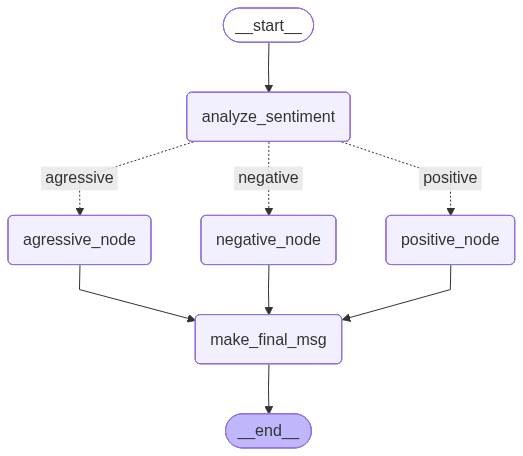

In [52]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(TeacherState)

# 노드등록
graph.add_node('analyze_sentiment', analyze_sentiment)
graph.add_node('positive_node', positive_node)
graph.add_node('negative_node', negative_node)
graph.add_node('agressive_node', agressive_node)
graph.add_node('make_final_msg', make_final_msg)

# 엣지등록
graph.add_edge(START, 'analyze_sentiment')
graph.add_conditional_edges(
    'analyze_sentiment',
    router,
    {       # router 결과값: 다음 노드명
        'positive': 'positive_node',
        'negative': 'negative_node',
        'agressive': 'agressive_node'
    }
)
graph.add_edge('positive_node', 'make_final_msg')
graph.add_edge('negative_node', 'make_final_msg')
graph.add_edge('agressive_node', 'make_final_msg')
graph.add_edge('make_final_msg', END)

app = graph.compile()
app

In [53]:
app.invoke({'user_input': '나 너무 우울해'})

{'user_input': '나 너무 우울해',
 'sentiment': 'negative',
 'core_msg': '괜찮',
 'response': '괜찮아, 그런 감정을 느끼는 건 자연스러운 일이야. 혼자 힘들어하지 말고 주변에 이야기해봐도 좋아. 필요하면 언제든 도움을 청하는 것도 괜찮아.'}